# Week 4 — Jupyter Notebook (Group 1)


*   Ione Axelrod
*   David Chang
*   Azin Shahrokhi


**Dataset:** Adult Income (UCI Machine Learning Repository)

# Part 0 — Choose a Dataset

Dataset: Adult Income (UCI Machine Learning Repository)

Dataset source (link): https://archive.ics.uci.edu/dataset/2/adult

# Part 1 — Load the Dataset
**Step 1:** Import Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


**Part 1** - **Step 2**: Load the CSV

In [4]:
df = pd.read_csv("adult.data")
df.head()

,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
0,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
1,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
2,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
3,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
4,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K


# Part 2 — Inspect the Data
**Step 3:** Dataset Overview

In [5]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32560 entries, 0 to 32559
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   39              32560 non-null  int64 
 1    State-gov      32560 non-null  object
 2    77516          32560 non-null  int64 
 3    Bachelors      32560 non-null  object
 4    13             32560 non-null  int64 
 5    Never-married  32560 non-null  object
 6    Adm-clerical   32560 non-null  object
 7    Not-in-family  32560 non-null  object
 8    White          32560 non-null  object
 9    Male           32560 non-null  object
 10   2174           32560 non-null  int64 
 11   0              32560 non-null  int64 
 12   40             32560 non-null  int64 
 13   United-States  32560 non-null  object
 14   <=50K          32560 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


# Part 3 — Data Quality Checks
**Step 5:** Missing Values

In [6]:
df.isna().sum()

,0
39,0
State-gov,0
77516,0
Bachelors,0
13,0
Never-married,0
Adm-clerical,0
Not-in-family,0
White,0
Male,0


# Part 3
**Step 6: Duplicate Rows**

In [7]:
df.duplicated().sum()

np.int64(24)

# Part 4 — Selecting Features and Target

In [8]:
df.columns = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week", "native_country",
    "income"
]

df.head()

target_col = "income"
# Choose your features (readable by humans from values)
feature_cols = ["education", "marital_status", "race", "hours_per_week"]
# Create modeling dataset
df_model = df[feature_cols + [target_col]]

df_model.head()

,education,marital_status,race,hours_per_week,income
0,Bachelors,Married-civ-spouse,White,13,<=50K
1,HS-grad,Divorced,White,40,<=50K
2,11th,Married-civ-spouse,Black,40,<=50K
3,Bachelors,Married-civ-spouse,Black,40,<=50K
4,Masters,Married-civ-spouse,White,40,<=50K


# Part 5 - NumPy Operations

In [9]:
X = df_model[feature_cols].to_numpy()
y = df_model[target_col].to_numpy()

print("X shape:", X.shape)
print("y shape:", y.shape)

hours = df_model["hours_per_week"].to_numpy()
print("Mean hours per week:", np.mean(hours))
print("Standard deviation:", np.std(hours))
print("Minimum hours:", np.min(hours))
print("Maximum hours:", np.max(hours))


X shape: (32560, 4)
y shape: (32560,)
Mean hours per week: 40.437469287469284
Standard deviation: 12.34742844372421
Minimum hours: 1
Maximum hours: 99


# Part 6 - Basic Cleaning
**Step 7**: Handle Missing Values

In [10]:
print("Missing values BEFORE cleaning:")
print(df_model.isna().sum())
print("-" * 40)
# 2. Fill missing numeric values (only hours_per_week)
#df_model["hours_per_week"] = df_model["hours_per_week"].fillna(df_model["hours_per_week"].median())


Missing values BEFORE cleaning:
education         0
marital_status    0
race              0
hours_per_week    0
income            0
dtype: int64
----------------------------------------


### Observations (Missing Values)
The output above shows how many missing values exist in each selected column.
If a column has missing values, we need to handle them (for example, filling with a median for numeric columns or the most common value for categorical columns).

# Part 7 — Simple Visualization
**Step 1 - Draw a Bar Chart (Income Distribution )**

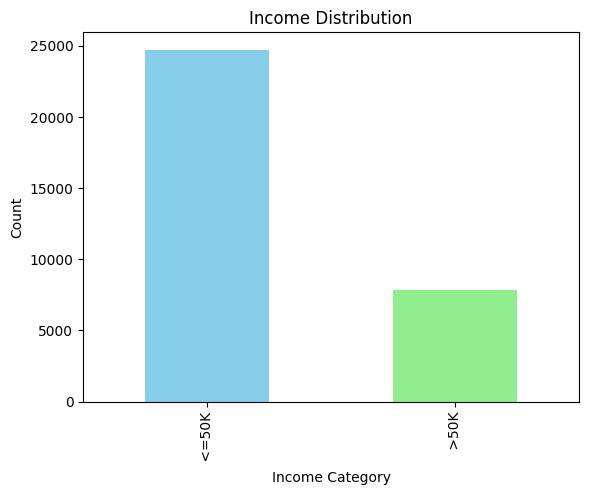

In [11]:
import matplotlib.pyplot as plt

# Bar chart of income categories
df_model["income"].value_counts().plot(kind="bar", color=["skyblue", "lightgreen"])

plt.title("Income Distribution")
plt.xlabel("Income Category")
plt.ylabel("Count")
plt.show()

# Observations (Bar Chart)
The bar chart shows how many records fall into each income category (`<=50K` vs `>50K`).
In this dataset, the `<=50K` category is typically much larger, which suggests **class imbalance** (one class has more examples than the other).



# Part 7 - Simple Visualization
**Step 2 - Scatter Plot(Hours Worked vs Income)**
Shows the relationship between hours worked and income category

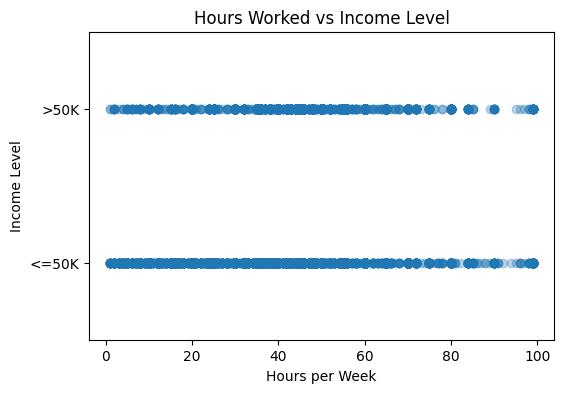

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the dataset
df = pd.read_csv("adult.data", header=None)

# 2. Assign column names
df.columns = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week", "native_country",
    "income"
]

# 3. Build df_model with your chosen features + target
feature_cols = ["education", "marital_status", "race", "hours_per_week"]
target_col = "income"

# use copy to not changing the original data_frame
df_model = df[feature_cols + [target_col]].copy()

# 4. Clean income strings and map to numeric 0/1
df_model["income"] = df_model["income"].str.strip()
df_model["income_num"] = df_model["income"].map({"<=50K": 0, ">50K": 1})


# 5. Scatter plot: Hours vs Income Level
plt.figure(figsize=(6, 4))

plt.scatter(df_model["hours_per_week"], df_model["income_num"], alpha=0.3)

# Make the y-axis easier to read
plt.ylim(-0.5, 1.5)
plt.yticks([0, 1], ["<=50K", ">50K"])

plt.xlabel("Hours per Week")
plt.ylabel("Income Level")
plt.title("Hours Worked vs Income Level")

plt.show()



# Observations (Scatter Plot)
Each point represents one person: x-axis is hours per week and y-axis is the income class. Most points for both classes overlap in the same hours range (often around full-time hours), so hours per week alone may not be enough to separate the two income groups.



# Part 8 - Reflection Questions
**1. Which repository did you choose and why?**
I chose the UCI Machine Learning Repository and used the Adult Income dataset. I picked it because it’s easy to download as a CSV, it has a mix of numeric and categorical columns, and it’s a very common dataset used in machine learning classes. It also meets all the assignment requirements without needing any extra formatting.

***2. What problems did you find in the dataset?***
In the columns I selected, I did not find missing values. However, I did encounter a formatting issue in the income column. Some values contained extra leading spaces (for example, " <=50K" instead of "<=50K").

This caused a problem when I tried to convert the income categories into numeric values for plotting, because the mapping did not match correctly and resulted in missing values. I had to clean the column using string operations to remove the extra spaces before creating the numeric version of the target variable.

This experience showed me how small formatting issues in real-world datasets can affect analysis and visualization.

***3. Which pandas functions were most useful?***

Several pandas functions were especially helpful during this lab.
df.head() allowed me to preview the dataset and verify that it loaded correctly.
df.info() helped me understand the data types and check for missing values.
df.isna().sum() made it easy to identify whether any columns contained null values.
Additionally, the .str.strip() function was very useful when cleaning the income column. Some values contained extra spaces, which caused issues when converting the column into numeric categories. Using .str.strip() helped remove those spaces and ensured the mapping worked correctly.

***4. What NumPy operations helped you understand the data?***
To better understand the numeric feature hours_per_week, I converted it into a NumPy array and applied several NumPy statistical functions.
Using np.mean() helped me find the average number of hours people work per week.
np.std() showed how much variation there is in working hours across individuals.
I also used np.min() and np.max() to understand the full range of working hours in the dataset.
These operations gave me a clearer understanding of how the values are distributed and whether there are extreme cases (for example, people working very high numbers of hours).

**5. What would you need to do before building a good ML model?**
Before building a model, I would need to make sure the data is clean and properly formatted. In this lab, I checked data types, cleaned formatting issues like extra spaces, and identified which features are numeric or categorical. I would also need to encode categorical variables into numeric form before training a model.
